<a href="https://colab.research.google.com/github/BU-Spark/ds-bcc-tree-canopy/blob/dev-Grace-ej/EJ_Weber_CT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

For EJ Communities Question: Are there inequities in tree-canopy coverage between neighborhoods, particularly in marginalized communities?

We have a measure of social vulnerability (race, income, disability, language, etc.) for each census tract in Boston.

We have a measure of tree-canopy coverage for each tract.

We want to know: Do tracts with higher social-vulnerability scores systematically have less tree cover?



Aggregating EJ geojson and Percentage of Tree Canopy By Neighborhood csv.



In [ ]:
!pip install --quiet geopandas fiona pyproj rtree

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from scipy.stats import spearmanr


In [ ]:
# Load
uploaded = files.upload()
# → Select:
#    • Climate_Ready_Boston_Social_Vulnerability.geojson
#    • Canopy_Change_Assessment…Tree_Canopy_Metrics.geojson
#    • (optional) Percentage of Tree Canopy By Neighborhood – Sheet1.csv


Saving Canopy_Change_Assessment%3A_Tree_Canopy_Metrics.geojson to Canopy_Change_Assessment%3A_Tree_Canopy_Metrics.geojson
Saving Percentage of Tree Canopy By Neighborhood.xlsx - Sheet1.csv to Percentage of Tree Canopy By Neighborhood.xlsx - Sheet1.csv
Saving Climate_Ready_Boston_Social_Vulnerability.geojson to Climate_Ready_Boston_Social_Vulnerability.geojson
Saving boston_tracts_sv_canopy.geojson to boston_tracts_sv_canopy.geojson


In [ ]:
#Load
import os
geojsons = [f for f in os.listdir() if f.lower().endswith(".geojson")]
print("GeoJSON files found:", geojsons)

# Replace names here with exactly what printed above:
sv_file  = "Climate_Ready_Boston_Social_Vulnerability.geojson"
can_file = "Canopy_Change_Assessment%3A_Tree_Canopy_Metrics.geojson"

# Read into GeoDataFrames
sv  = gpd.read_file(sv_file)    # social vulnerability by tract
can = gpd.read_file(can_file)   # canopy metrics by tract

print("SV columns:", sv.columns.tolist())
print("Canopy columns:", can.columns.tolist())


GeoJSON files found: ['boston_tracts_sv_canopy (1).geojson', 'boston_tracts_sv_canopy (2).geojson', 'boston_tracts_sv_canopy (3).geojson', 'Canopy_Change_Assessment%3A_Tree_Canopy_Metrics (1).geojson', 'Canopy_Change_Assessment%3A_Tree_Canopy_Metrics (4).geojson', 'Boston_Neighborhoods_SV_Canopy.geojson', 'Canopy_Change_Assessment%3A_Tree_Canopy_Metrics (2).geojson', 'Climate_Ready_Boston_Social_Vulnerability (2).geojson', 'Canopy_Change_Assessment%3A_Tree_Canopy_Metrics.geojson', 'Climate_Ready_Boston_Social_Vulnerability (3).geojson', 'Climate_Ready_Boston_Social_Vulnerability.geojson', 'Climate_Ready_Boston_Social_Vulnerability (4).geojson', 'Canopy_Change_Assessment%3A_Tree_Canopy_Metrics (3).geojson', 'boston_tracts_sv_canopy.geojson', 'Climate_Ready_Boston_Social_Vulnerability (1).geojson']
SV columns: ['FID', 'GEOID10', 'AREA_SQFT', 'AREA_ACRES', 'POP100_RE', 'HU100_RE', 'TotDis', 'TotChild', 'OlderAdult', 'Low_to_No', 'LEP', 'POC2', 'MedIllnes', 'Name', 'Shape__Area', 'Shape__L

# Merged the EJ and the canopy GeoJSONs on tract ID

In [ ]:
# Merge the two GeoDataFrames on census-tract ID

# Ensure matching types
sv["GEOID10"] = sv["GEOID10"].astype(str)
can["ID"]     = can["ID"].astype(str)

# Left-join vulnerability → canopy
df = sv.merge(
    can[["ID","TC_E_P"]],     # TC_E_P = Existing Tree Canopy Percentage
    left_on="GEOID10",
    right_on="ID",
    how="left"
)


# Normalized raw counts into percent‐based indicators

In [ ]:
# Normalize ALL the count fields into percentages

# percent of people with disabilities
df["Disability_pct"] = df["TotDis"]     / df["POP100_RE"] * 100

# percent of people without basic utilities
df["LowIncome_pct"] = df["Low_to_No"]  / df["POP100_RE"] * 100

# percent of children
df["Child_pct"]       = df["TotChild"]   / df["POP100_RE"] * 100

# percent of older adults
df["OlderAdult_pct"]  = df["OlderAdult"] / df["POP100_RE"] * 100


In [ ]:
print([c for c in df.columns if c.endswith("_pct")])


['Disability_pct', 'LowIncome_pct', 'Child_pct', 'OlderAdult_pct']


# Checked each indicator’s Pearson r with canopy %

Pearson r tells us how strongly “higher vulnerability” (e.g. % LEP, % low‐income) is associated with “lower canopy %” in a linear sense.



Both are negative, meaning as the %LEP or the % low‐income goes up, canopy % tends to go down.

The magnitude (~0.15–0.17) is small‐to‐moderate, but among all indicators it’s the clearest downward trend.

The p‐values (~0.05 and ~0.03) tell us these negative slopes are unlikely to be due to random chance alone.

In [ ]:
from scipy.stats import pearsonr
pct_cols = ["POC2","LEP","MedIllnes",
            "Disability_pct","LowIncome_pct",
            "Child_pct","OlderAdult_pct"]

# Drop any tracts with missing data
analysis_df = df.dropna(subset=pct_cols + ["TC_E_P"]).copy()

print("Indicator correlations with canopy %:")
for var in pct_cols:
    r, p = pearsonr(analysis_df[var], analysis_df["TC_E_P"])
    print(f"  {var:15s} r = {r: .2f}, p = {p:.3f}")


Indicator correlations with canopy %:
  POC2            r =  0.01, p = 0.869
  LEP             r = -0.15, p = 0.052
  MedIllnes       r = -0.13, p = 0.093
  Disability_pct  r =  0.30, p = 0.000
  LowIncome_pct   r = -0.17, p = 0.028
  Child_pct       r =  0.13, p = 0.076
  OlderAdult_pct  r =  0.36, p = 0.000


In [ ]:
# ─── Prepare a clean “analysis_df” ──────────────────────────────────────────
pct_cols = ["POC2","LEP","MedIllnes","Disability_pct","LowIncome_pct","Child_pct","OlderAdult_pct"]
# Drop any tracts missing any indicator or canopy
analysis_df = df.dropna(subset=pct_cols + ["TC_E_P"]).copy()
print(f"Using {len(analysis_df)} tracts (dropped {len(df)-len(analysis_df)})")


Using 177 tracts (dropped 3)


# Built a simple two‐field index (SV_key = LEP + LowIncome_pct), quartiled it, and showed it yields a clearer drop in mean canopy from Q0→Q3

In [ ]:
# 1. Build the two-field index
analysis_df["SV_key"] = analysis_df["LEP"] + analysis_df["LowIncome_pct"]

# 2. Quartile-bin it (0 lowest, 3 highest)
analysis_df["SV_key_q"] = pd.qcut(analysis_df["SV_key"], 4, labels=False)

# 3. Check correlation
r_key, p_key = pearsonr(analysis_df["SV_key"], analysis_df["TC_E_P"])
print(f"\nLEP+LowIncome composite: r = {r_key:.3f}, p = {p_key:.3f}")

# 4. Summarize mean canopy by quartile
summary_key = (
    analysis_df
      .groupby("SV_key_q")["TC_E_P"]
      .agg(mean_canopy="mean", n_tracts="count")
      .reset_index()
)
print("\nMean canopy % by LEP+LowIncome quartile:")
print(summary_key)



LEP+LowIncome composite: r = -0.148, p = 0.050

Mean canopy % by LEP+LowIncome quartile:
   SV_key_q  mean_canopy  n_tracts
0         0    24.864652        45
1         1    23.838748        44
2         2    23.050894        44
3         3    20.914465        44


# Tested a full PCA‐derived index and confirmed it performs worse (r≈–0.03)

In [ ]:
from sklearn.decomposition import PCA

# 1. Fit PCA (1 component) on the percent columns
pca = PCA(n_components=1)
analysis_df["SV_PC1"] = pca.fit_transform(analysis_df[pct_cols])

# 2. Test Pearson correlation
r_pc, p_pc = pearsonr(analysis_df["SV_PC1"], analysis_df["TC_E_P"])
print(f"\nPCA-based index: r = {r_pc:.3f}, p = {p_pc:.3f}")

# 3. (Optional) Quartile & summary
analysis_df["SV_pc_q"] = pd.qcut(analysis_df["SV_PC1"], 4, labels=False)
summary_pc = (
    analysis_df
      .groupby("SV_pc_q")["TC_E_P"]
      .agg(mean_canopy="mean", n="count")
      .reset_index()
)
print("\nMean canopy % by PCA quartile:")
print(summary_pc)



PCA-based index: r = -0.033, p = 0.665

Mean canopy % by PCA quartile:
   SV_pc_q  mean_canopy   n
0        0    24.762212  45
1        1    22.888038  44
2        2    21.644095  44
3        3    23.376742  44


#NEW method!

In [ ]:
import geopandas as gpd
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

tracts = gpd.read_file("boston_tracts_sv_canopy.geojson")

In [ ]:
# ─── 1) Load tract GeoJSON ──────────────────────────────────────────────────
tracts = gpd.read_file("boston_tracts_sv_canopy.geojson")

# ─── 2) Compute tract‐level percent fields ───────────────────────────────────
tracts["LEP_pct"]       = tracts["LEP"]       / tracts["POP100_RE"] * 100
tracts["Disability_pct"] = tracts["TotDis"]     / tracts["POP100_RE"] * 100
tracts["LowIncome_pct"]  = tracts["Low_to_No"]  / tracts["POP100_RE"] * 100

# ─── 3) Load & clean neighborhood canopy CSV ────────────────────────────────
can_nb = pd.read_csv("Percentage of Tree Canopy By Neighborhood.xlsx - Sheet1.csv")
can_nb["Canopy_pct"] = can_nb["Existing Tree Canopy Percentage"] \
                         .str.rstrip("%").astype(float)

In [ ]:
# 1) Drop any NaNs and ensure everything’s a string
names = can_nb["Name"].dropna().astype(str).unique()

# 2) Sort and print
print(sorted(names))


['Allston-Brighton', 'Back Bay/Beacon Hill', 'Central Boston', 'Charlestown', 'Dorchester', 'East Boston', 'Fenway/Longwood', 'Harbor Islands', 'Hyde Park', 'Jamaica Plain', 'Mattapan', 'Mission Hill', 'Roslindale', 'Roxbury', 'South Boston', 'South End', 'West Roxbury']


In [ ]:
# ─── 4) Map tract “Name” → official canopy‐CSV “Name” ───────────────────────
nb_map = {
    "Allston":      "Allston-Brighton",  "Brighton":        "Allston-Brighton",
    "Back Bay":     "Back Bay/Beacon Hill","Beacon Hill":    "Back Bay/Beacon Hill",
    "Fenway":       "Fenway/Longwood","Longwood Medical Area":"Fenway/Longwood",
    "North End":    "Central Boston","Bay Village":      "Central Boston","Leather District":"Central Boston",
    "South Boston Waterfront":"South Boston",
    # direct 1:1 matches for the rest
    "Central Boston":"Central Boston","Charlestown":"Charlestown",
    "Dorchester":"Dorchester","East Boston":"East Boston","Harbor Islands":"Harbor Islands",
    "Hyde Park":"Hyde Park","Jamaica Plain":"Jamaica Plain","Mattapan":"Mattapan",
    "Mission Hill":"Mission Hill","Roslindale":"Roslindale","Roxbury":"Roxbury",
    "South Boston":"South Boston","South End":"South End","West Roxbury":"West Roxbury",
    # catch any stragglers
    "West End":"Central Boston"
}
tracts["NB_Name"] = tracts["Name"].replace(nb_map)

# sanity check: should print an empty set
unmatched = set(tracts["NB_Name"].unique()) - set(can_nb["Name"])
print("Unmatched after mapping:", unmatched)

Unmatched after mapping: set()


In [ ]:
# ─── 5) Pop‐weighted aggregation to neighborhoods ───────────────────────────
vuln_cols = ["LEP_pct", "LowIncome_pct"]
def pop_wmean(g,col):
    return (g[col] * g["POP100_RE"]).sum() / g["POP100_RE"].sum()

neigh_vuln = (
    tracts
      .groupby("NB_Name")
      .apply(lambda g: pd.Series({col: pop_wmean(g,col) for col in vuln_cols}))
      .reset_index()
      .rename(columns={"NB_Name":"Name"})
)


<ipython-input-216-f25b9bb41cfd>:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({col: pop_wmean(g,col) for col in vuln_cols}))


In [ ]:
# ─── 6) Build neighborhood SV index & merge canopy ────────────────────────
neigh_vuln["SV_key_nb"] = neigh_vuln["LEP_pct"] + neigh_vuln["LowIncome_pct"]
neigh = pd.merge(
    neigh_vuln,
    can_nb[["Name","Canopy_pct"]],
    on="Name",
    how="left"
)



In [ ]:
# ─── 7) Compute Pearson r & p-value ────────────────────────────────────────
r_nb, p_nb = pearsonr(neigh["SV_key_nb"], neigh["Canopy_pct"])
print(f"\nNeighborhood LEP+LowIncome → Canopy: r = {r_nb:.3f}, p = {p_nb:.3f}")


Neighborhood LEP+LowIncome → Canopy: r = -0.037, p = 0.889


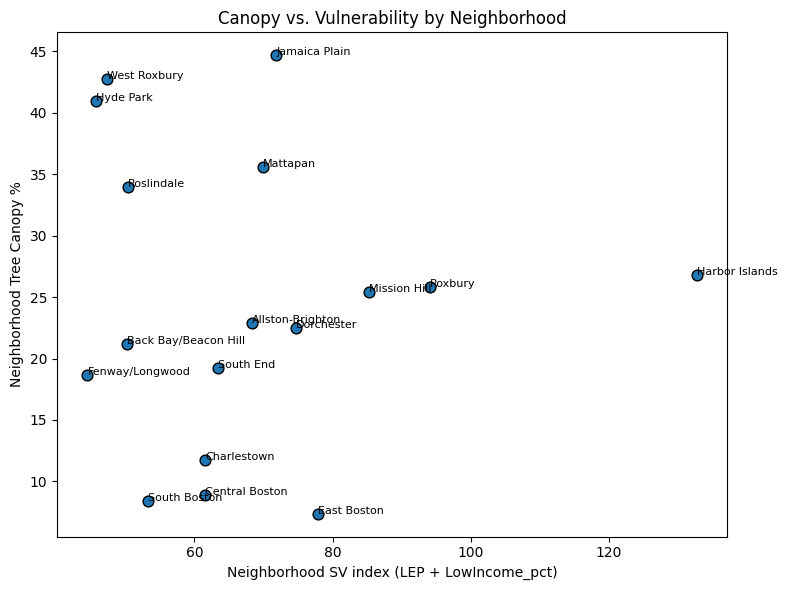

In [ ]:
# ─── 8) Scatterplot of the result ─────────────────────────────────────────
plt.figure(figsize=(8,6))
plt.scatter(neigh["SV_key_nb"], neigh["Canopy_pct"], s=60, edgecolor="k")
for _, row in neigh.iterrows():
    plt.text(row["SV_key_nb"], row["Canopy_pct"], row["Name"], fontsize=8)
plt.xlabel("Neighborhood SV index (LEP + LowIncome_pct)")
plt.ylabel("Neighborhood Tree Canopy %")
plt.title("Canopy vs. Vulnerability by Neighborhood")
plt.tight_layout()
plt.show()

In [ ]:
print(summary_nb)


   SV_q_nb  mean_canopy  n_neigh
0        0      17.3620        5
1        1      26.2175        4
2        2      35.9275        4
3        3      20.3650        4


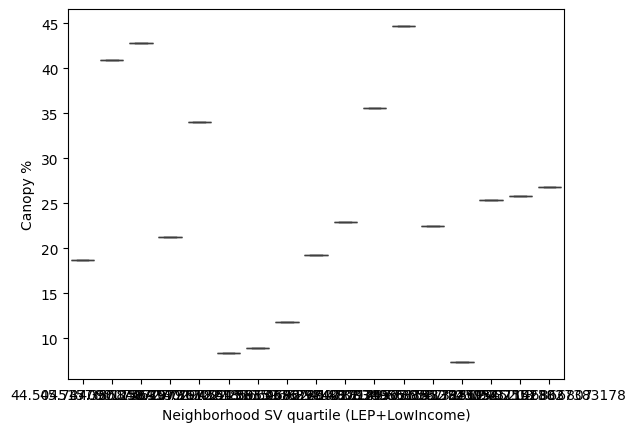

In [ ]:
import seaborn as sns
sns.boxplot(x="SV_key_nb", y="Canopy_pct", data=neigh )
plt.xlabel("Neighborhood SV quartile (LEP+LowIncome)")
plt.ylabel("Canopy %")
plt.show()


In [ ]:
# ─── 3) Load & clean the neighborhood canopy CSV ────────────────────────────
can_nb = pd.read_csv("Percentage of Tree Canopy By Neighborhood.xlsx - Sheet1.csv")

# Strip the “%” and convert to float
can_nb["Canopy_pct"] = (
    can_nb["Existing Tree Canopy Percentage"]
      .str.rstrip("%")
      .astype(float)
)

# Keep only the columns we need
can_nb = can_nb[["Name", "Canopy_pct"]]

In [ ]:
# ─── 4) Map tract “Name” → official neighborhood “Name” ─────────────────────
# Tract-level micro-neighborhoods need to be bucketed into the 17 canopy CSV neighborhoods
nb_map = {
    "Allston":      "Allston-Brighton",   "Brighton":      "Allston-Brighton",
    "Back Bay":     "Back Bay/Beacon Hill","Beacon Hill":  "Back Bay/Beacon Hill",
    "Fenway":       "Fenway/Longwood",     "Longwood Medical Area": "Fenway/Longwood",
    "North End":    "Central Boston",      "Bay Village":  "Central Boston",
    "Leather District":"Central Boston",
    "West End":     "Central Boston",      # catch one straggler
    "South Boston Waterfront":"South Boston",
    # 1:1 mappings for the rest
    "Central Boston":"Central Boston",  "Charlestown":"Charlestown",
    "Dorchester":"Dorchester",          "East Boston":"East Boston",
    "Harbor Islands":"Harbor Islands",  "Hyde Park":"Hyde Park",
    "Jamaica Plain":"Jamaica Plain",    "Mattapan":"Mattapan",
    "Mission Hill":"Mission Hill",      "Roslindale":"Roslindale",
    "Roxbury":"Roxbury",               "South Boston":"South Boston",
    "South End":"South End",            "West Roxbury":"West Roxbury"
}


In [ ]:
# Apply the mapping
tracts["NB_Name"] = tracts["Name"].replace(nb_map)

# Sanity‐check: no unmatched tract names should remain
unmatched = set(tracts["NB_Name"].unique()) - set(can_nb["Name"])
assert len(unmatched) == 0, f"Unmapped tract names: {unmatched}"

In [ ]:
# ─── 5) Population‐weighted aggregation to neighborhoods ────────────────────
# Define the list of vulnerability fields to aggregate
vuln_cols = ["LEP_pct", "LowIncome_pct", "Disability_pct"]  # add more if you like

def pop_wmean(group, col):
    """Compute the population-weighted mean of `col` within the group."""
    numer = (group[col] * group["POP100_RE"]).sum()
    denom = group["POP100_RE"].sum()
    return numer / denom if denom>0 else None

# Group by NB_Name and apply pop-weighted mean to each vuln_col
neigh_vuln = (
    tracts
      .groupby("NB_Name")[vuln_cols + ["POP100_RE"]]
      .apply(lambda g: pd.Series({col: pop_wmean(g, col) for col in vuln_cols}))
      .reset_index()
      .rename(columns={"NB_Name":"Name"})
)


In [ ]:
# ─── 6) Build a simple composite index if desired ───────────────────────────
# For example, LEP + LowIncome_pct
neigh_vuln["SV_key_nb"] = neigh_vuln["LEP_pct"] + neigh_vuln["LowIncome_pct"]

# ─── 7) Merge in neighborhood canopy % ──────────────────────────────────────
neigh = pd.merge(
    neigh_vuln,
    can_nb,
    on="Name",
    how="left"
)

# Sanity‐check: ensure no missing canopy values
missing = neigh[neigh["Canopy_pct"].isna()]["Name"].tolist()
assert not missing, f"Missing canopy % for: {missing}"

In [ ]:
# ─── 8) Re-attach geometries & export to GeoJSON ────────────────────────────
# Dissolve all tracts into full neighborhood polygons
nb_geo = (
    tracts
      .dissolve(by="NB_Name", as_index=False)[["NB_Name","geometry"]]
      .rename(columns={"NB_Name":"Name"})
)

# Then merge just as before
neigh_gdf = pd.merge(
    pd.DataFrame(neigh),    # your attribute table
    nb_geo,                 # now full dissolved shapes
    on="Name",
    how="left"
)

neigh_gdf = gpd.GeoDataFrame(neigh_gdf, geometry="geometry", crs=tracts.crs)
neigh_gdf.to_file("Boston_Neighborhoods_SVscore_Canopy.geojson", driver="GeoJSON")

In [ ]:
# Export the final neighborhoods shapefile/GeoJSON
neigh_gdf.to_file("Boston_Neighborhoods_SVscore_Canopyy.geojson", driver="GeoJSON")

print("✔️ Exported `Boston_Neighborhoods_SVscore_Canopy.geojson` with "
      f"{len(neigh_gdf)} neighborhoods.")

✔️ Exported `Boston_Neighborhoods_SVscore_Canopy.geojson` with 17 neighborhoods.


In [ ]:
from google.colab import files
files.download('Boston_Neighborhoods_SVscore_Canopy.geojson')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import geopandas as gpd

# read it back in
nb = gpd.read_file("Boston_Neighborhoods_SVscore_Canopy.geojson")

# show the attribute table’s first few rows
print(nb.head())

# list all columns (properties)
print(nb.columns.tolist())


                   Name    LEP_pct  LowIncome_pct  Disability_pct  SV_key_nb  \
0      Allston-Brighton  38.527765      29.770658        8.627015  68.298423   
1  Back Bay/Beacon Hill  31.693092      18.565342        6.607530  50.258434   
2        Central Boston  37.460788      24.080524        8.371002  61.541312   
3           Charlestown  36.303911      25.287426        9.337551  61.591338   
4            Dorchester  42.017361      32.640792       14.088529  74.658153   

   Canopy_pct                                           geometry  
0       22.88  POLYGON ((-71.14755 42.33707, -71.14847 42.336...  
1       21.19  MULTIPOLYGON (((-71.08142 42.34338, -71.08205 ...  
2        8.87  MULTIPOLYGON (((-71.0603 42.34503, -71.06064 4...  
3       11.76  MULTIPOLYGON (((-71.05755 42.37218, -71.05621 ...  
4       22.48  MULTIPOLYGON (((-71.06418 42.28618, -71.06425 ...  
['Name', 'LEP_pct', 'LowIncome_pct', 'Disability_pct', 'SV_key_nb', 'Canopy_pct', 'geometry']
